In [3]:
import kagglehub
path = kagglehub.dataset_download("yogesh174/nyc-taxi")
path

'C:\\Users\\Admin\\.cache\\kagglehub\\datasets\\yogesh174\\nyc-taxi\\versions\\1'

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [5]:
print(os.listdir(path))

['train.csv']


In [6]:
df = pd.read_csv(os.path.join(path,"train.csv"))

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  str    
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  str    
 3   dropoff_datetime    1458644 non-null  str    
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  str    
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), str(4)
memory usage: 122.4 MB


In [8]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


## **cleaning**

In [23]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["pickup_datetime"].isna().sum()

np.int64(0)

In [10]:
df["pickup_datetime"].astype

<bound method NDFrame.astype of 0          2016-03-14 17:24:55
1          2016-06-12 00:43:35
2          2016-01-19 11:35:24
3          2016-04-06 19:32:31
4          2016-03-26 13:30:55
                  ...         
1458639    2016-04-08 13:31:04
1458640    2016-01-10 07:35:15
1458641    2016-04-22 06:57:41
1458642    2016-01-05 15:56:26
1458643    2016-04-05 14:44:25
Name: pickup_datetime, Length: 1458644, dtype: str>

In [11]:
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])
df["pickup_datetime"].info()

<class 'pandas.Series'>
RangeIndex: 1458644 entries, 0 to 1458643
Series name: pickup_datetime
Non-Null Count    Dtype         
--------------    -----         
1458644 non-null  datetime64[us]
dtypes: datetime64[us](1)
memory usage: 11.1 MB


In [12]:
df["dropoff_datetime"] = pd.to_datetime(df["dropoff_datetime"])
df["dropoff_datetime"].info()

<class 'pandas.Series'>
RangeIndex: 1458644 entries, 0 to 1458643
Series name: dropoff_datetime
Non-Null Count    Dtype         
--------------    -----         
1458644 non-null  datetime64[us]
dtypes: datetime64[us](1)
memory usage: 11.1 MB


In [13]:
df["passenger_count"].value_counts()

passenger_count
1    1033540
2     210318
5      78088
3      59896
6      48333
4      28404
0         60
7          3
9          1
8          1
Name: count, dtype: int64

In [14]:
df["trip_duration"].head()

0     455
1     663
2    2124
3     429
4     435
Name: trip_duration, dtype: int64

## **individual study**

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id                  1458644 non-null  str           
 1   vendor_id           1458644 non-null  int64         
 2   pickup_datetime     1458644 non-null  datetime64[us]
 3   dropoff_datetime    1458644 non-null  datetime64[us]
 4   passenger_count     1458644 non-null  int64         
 5   pickup_longitude    1458644 non-null  float64       
 6   pickup_latitude     1458644 non-null  float64       
 7   dropoff_longitude   1458644 non-null  float64       
 8   dropoff_latitude    1458644 non-null  float64       
 9   store_and_fwd_flag  1458644 non-null  str           
 10  trip_duration       1458644 non-null  int64         
dtypes: datetime64[us](2), float64(4), int64(3), str(2)
memory usage: 122.4 MB


average pickup datetime is :13.60648383018749


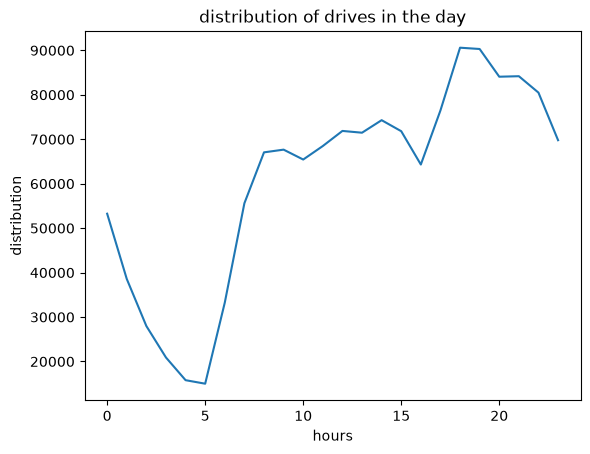

In [16]:
print(f"average pickup datetime is :{df["pickup_datetime"].dt.hour.mean()}")
hours = df["pickup_datetime"].dt.hour.value_counts().sort_index()
plt.figure()
plt.title("distribution of drives in the day")
plt.xlabel("hours")
plt.ylabel("distribution")
plt.plot(hours.index,hours.values)
plt.show()

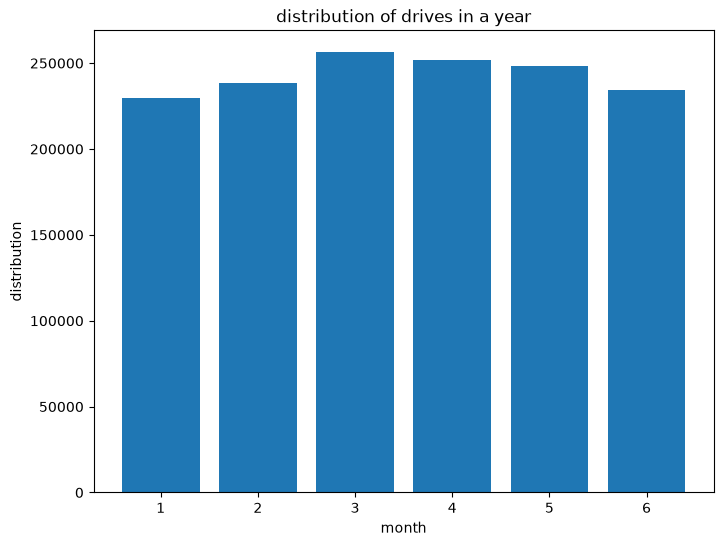

In [17]:
months = df["pickup_datetime"].dt.month.value_counts().sort_index()
plt.figure(figsize=(8, 6))
plt.title("distribution of drives in a year")
plt.xlabel("month")
plt.ylabel("distribution")
plt.bar(months.index,months.values)
plt.show()

average of number of passengers is : 1.6645295219395548


<BarContainer object of 10 artists>

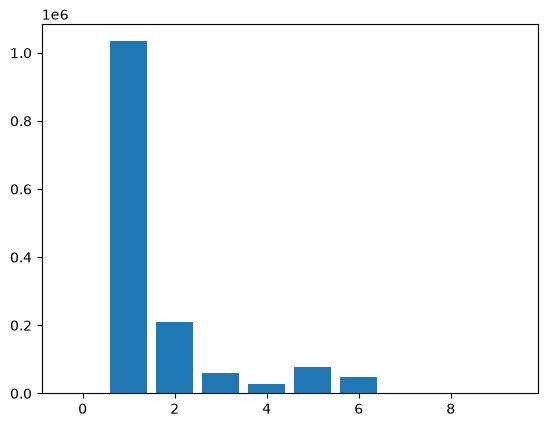

In [18]:
passenger_count = df["passenger_count"].value_counts()
print(f"average of number of passengers is : {df["passenger_count"].mean()}")
plt.figure()
plt.bar(passenger_count.index,passenger_count.values)

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id                  1458644 non-null  str           
 1   vendor_id           1458644 non-null  int64         
 2   pickup_datetime     1458644 non-null  datetime64[us]
 3   dropoff_datetime    1458644 non-null  datetime64[us]
 4   passenger_count     1458644 non-null  int64         
 5   pickup_longitude    1458644 non-null  float64       
 6   pickup_latitude     1458644 non-null  float64       
 7   dropoff_longitude   1458644 non-null  float64       
 8   dropoff_latitude    1458644 non-null  float64       
 9   store_and_fwd_flag  1458644 non-null  str           
 10  trip_duration       1458644 non-null  int64         
dtypes: datetime64[us](2), float64(4), int64(3), str(2)
memory usage: 122.4 MB


average of drip duration is : 959.4922729603659 seconds


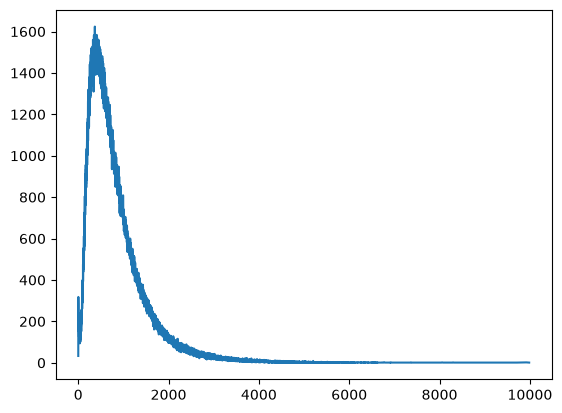

In [20]:
df_duration = df[df["trip_duration"] < 10000]
print(f"average of drip duration is : {df["trip_duration"].mean()} seconds")
duration = df_duration["trip_duration"].value_counts().sort_index()
plt.figure()
plt.plot(duration.index,duration.values)
plt.show()

In [21]:
df["trip_duration"].info()

<class 'pandas.Series'>
RangeIndex: 1458644 entries, 0 to 1458643
Series name: trip_duration
Non-Null Count    Dtype
--------------    -----
1458644 non-null  int64
dtypes: int64(1)
memory usage: 11.1 MB


In [22]:
df.duplicated().sum()

np.int64(0)

In [26]:
df.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration'],
      dtype='str')

## **distance column**

In [30]:
R = 6371
lat1 = np.radians(df["pickup_latitude"])
lat2 = np.radians(df["dropoff_latitude"])

long1 = np.radians(df["pickup_longitude"])
long2 = np.radians(df["dropoff_longitude"])

dlat = lat2 - lat1
dlong = long2 - long1

a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2) * np.sin(dlong/2)**2

df["distance_km"] = 2 * R * np.arcsin(np.sqrt(a))
df[["distance_km","trip_duration"]].head()

,distance_km,trip_duration
0,1.498521,455
1,1.805507,663
2,6.385098,2124
3,1.485498,429
4,1.188588,435


## **speed**

In [32]:
df["average speed_km/h"]  = df["distance_km"] / (df["trip_duration"] / 3600)
df["average speed_km/h"].head()

0    11.856428
1     9.803659
2    10.822201
3    12.465721
4     9.836594
Name: average speed_km/h, dtype: float64

## **multi variable study**

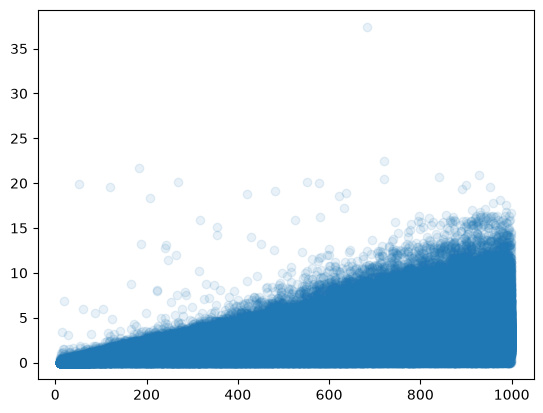

In [47]:
df_duration_distance = df[
    (df["trip_duration"] > 10) &
    (df["trip_duration"] < 1000) &
    (df["distance_km"] < 50)
]
plt.figure()
plt.scatter(df_duration_distance["trip_duration"],df_duration_distance["distance_km"],alpha=0.1)
plt.show()

In [48]:
df_duration_distance.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,distance_km,average speed_km/h
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,1.498521,11.856428
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,1.805507,9.803659
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,1.485498,12.465721
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,1.188588,9.836594
5,id0801584,2,2016-01-30 22:01:40,2016-01-30 22:09:03,6,-73.982857,40.742195,-73.992081,40.749184,N,443,1.098942,8.930458


In [53]:
group_by_passengers = df.groupby("passenger_count")
group_by_passengers["average speed_km/h"].mean()

passenger_count
0     10.418566
1     14.443585
2     14.408575
3     14.186431
4     14.099450
5     14.558084
6     14.319128
7      0.267590
8    206.025664
9      0.000000
Name: average speed_km/h, dtype: float64

In [68]:
df_duration_distance["hour"] = df_duration_distance["pickup_datetime"].dt.hour 
group_by_hours = df_duration_distance.groupby("hour")


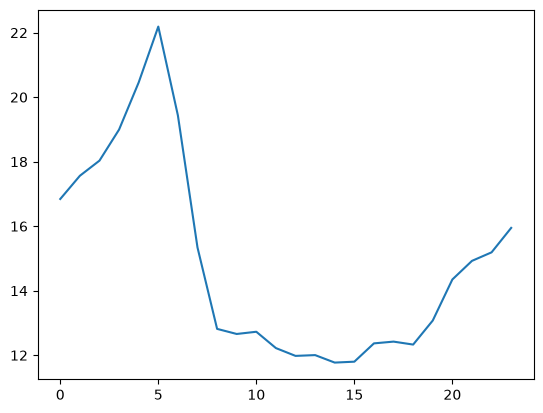

In [70]:
plot_hours_by_speed = group_by_hours["average speed_km/h"].mean()
plt.figure()
plt.plot(plot_hours_by_speed.index,plot_hours_by_speed.values) 
plt.show()

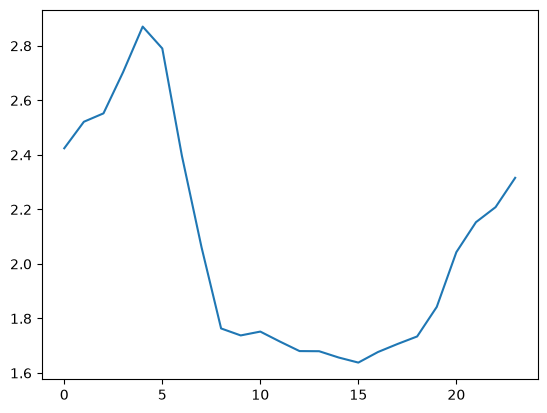

In [71]:
plot_hours_by_distance = group_by_hours["distance_km"].mean()
plt.figure()
plt.plot(plot_hours_by_distance.index,plot_hours_by_distance.values)
plt.show()